In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import os

In [2]:
def linear_func(x, k):
    return k*x


def straight_func(x, k, b):
    return k*x + b


class func_printer:
    def __init__(self, func, template=[], precision=3):
        self.func = func
        self.template = template
        self.precision = precision

    
    def print(self, *args, **kwargs):
        if "precision" in kwargs.keys():
            prec = kwargs["precision"]
        else:
            prec = self.precision
        form = "{0:0." + str(prec) + "f}"
        result = ""
        i = 0

        for step in self.template:
            if step not in set(range(2)):
                 result += step
                 continue
            
            if step == 0:
                result += str(form.format(args[i]))
                i += 1
                continue

            if step == 1:
                sign = "- " if args[i] < 0 else "+ "
                result += sign + str(form.format(np.abs(args[i])))
                i += 1
                continue
        return result


linear_func_printer = func_printer(
    linear_func,
    ["$y = ", 0, r"\cdot x$"],
    3
)

straight_func_printer = func_printer(
    straight_func,
    ["$y = ", 0, r"\cdot x ", 1, "$"],
    3
)

In [3]:
def plot(x, y, func: func_printer = None, xlim=None, ylim=None, xerror=None, yerror=None, ejects=None, lines=[], xlabel="", ylabel="", figsize=(12, 6), title="",
         dots_legend="", dots_args=["+r"], approx_legend="", name="graph", precision_print=3, func_dots_linspace=(None, None, 1000), dropna=False):
    '''
    Строит график и аппроксимирует его функцией

    :param x: массив иксов

    :param y: массив игриков

    :param func: объект, имеющий поля 
        func  -- вызываемая функция для аппроксимации;
        print -- метод, принимающий параметры и возвращающий строку

    :param xlim: параметр xlim для plt.plot

    :param ylim: параметр ylim для plt.plot

    :param xerror: массив погрешностей иксов

    :param yerror: массив погрешностей игриков

    :param ejects: список индексов точек, которые считаем выбросами (их выбрасываем)

    :param lines: list из tuple, где первый элемент либо "v" -- для вертикальной линии и "h" -- для горизонтальной.
        Второй элемент -- kwargs для plt.vlines или plt.hlines соответственно

    :param xlabel: название оси x для plt.xlabel

    :param ylabel: название оси y для plt.ylabel

    :param figsize: размер графика для plt.figure

    :param title: название графика для plt.title

    :param dots_legend: Подпись для точек для plt.plot

    :param dots_args: args для plt.plot

    :param approx_legend: подпись для аппроксимации для plt.plot

    :param name: имя под которым сохраним график в формате pdf, если передать None, то не сохраним

    :param precision_print: число знаков после запятой при выводе числе в легенде

    :param func_dots_range: args для np.linspace при построении графика, если какой-то из элементов None, то он пересчитывается автоматический, 
        в формате (None, None, None) -> (min(x), max(x), 1000)

    :param dropna: Проверять и выкидывать NaN и inf из x и y. Если False -- то нет

    return popt -- параметры функции
    return pcov -- ошибка предсказаня из curve_fit
    '''
    popt, pcov = None, None
    if ejects is not None:
        ejects = set(ejects)
    assert len(x) == len(y), "x and y must be the same size"

    if func is not None and ejects is not None:
        x_new, y_new = [], []
        for i in range(len(x)):
            if i not in ejects:
                x_new.append(x[i])
                y_new.append(y[i])
    else:
        x_new, y_new = x, y

    if dropna:
        mask_x = np.isfinite(x_new)
        mask_y = np.isfinite(y_new)

        _x, _y = [], []
        for i in range(len(x_new)):
            if mask_x[i] and mask_y[i]:
                _x.append(x_new[i])
                _y.append(y_new[i])
        x_new, y_new = _x, _y

    if func is not None:
        popt, pcov = curve_fit(func.func, xdata=x_new, ydata=y_new)

        linspace_args = (
            min(x_new) if func_dots_linspace[0] is None else func_dots_linspace[0],
            max(x_new) if func_dots_linspace[1] is None else func_dots_linspace[1],
            1000 if func_dots_linspace[2] is None else func_dots_linspace[2],
        )

        x_model = np.linspace(*linspace_args)
        y_model = func.func(x_model, *popt)

    
    plt.figure(figsize=figsize)

    for line in lines:
        if line[0] == "v":
            line_draw = plt.vlines
        else:
            line_draw = plt.hlines
        line_draw(**line[1])

    plt.grid(True, linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    if xerror is not None and yerror is not None:
        plt.errorbar(x_new, y_new, yerr=yerror, xerr=xerror, fmt="+r")
    else:
        plt.plot(x_new, y_new, *dots_args, label=dots_legend)

    if func is not None:
        leg = approx_legend + " " + func.print(*popt, precision=precision_print)
        plt.plot(x_model, y_model, color="blue", label=leg)
    plt.legend()
    if name is not None:
        plt.savefig(os.path.join("plots", f"{name}.pdf"), format="pdf")

    return popt, pcov

# Измерение с амперметром

Подключаем просто амперметр, к источнику и меряем

In [4]:
data_1 = pd.DataFrame({
    "I, muA": [1.25, 2.75, 5.75, 13,   21,   32,   50,   65,   68,   85,   100,  1170],
    "U, V":   [1667, 1820, 1937, 2032, 2155, 2304, 2415, 2469, 2525, 2566, 2594, 2695],
})
data_1

,"I, muA","U, V"
0,1.25,1667
1,2.75,1820
2,5.75,1937
3,13.00,2032
4,21.00,2155
5,32.00,2304
6,50.00,2415
7,65.00,2469
8,68.00,2525
9,85.00,2566


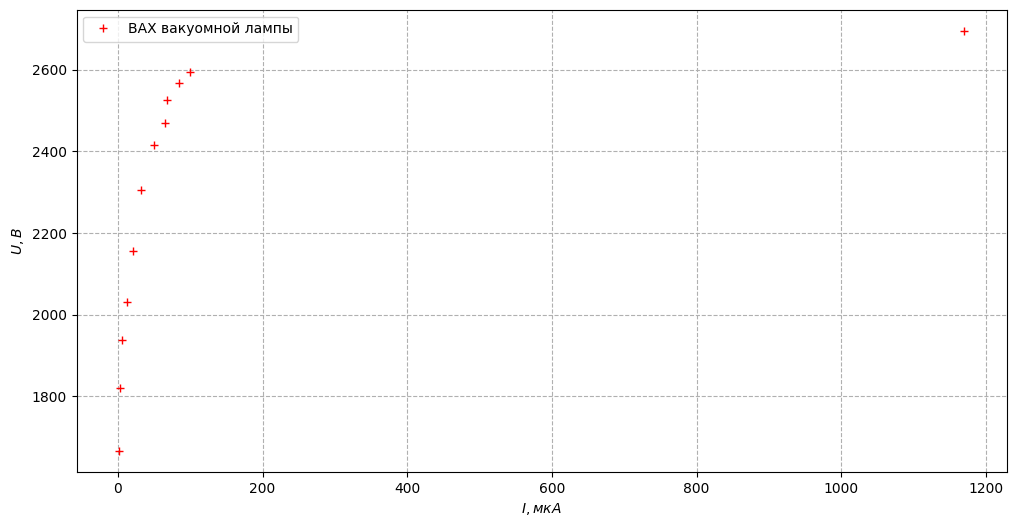

In [5]:
_ = plot(data_1["I, muA"], data_1["U, V"], xlabel=r"$I, мкА$", ylabel=r"$U, В$", dots_legend="ВАХ вакуомной лампы", name="graph_1")

In [6]:
data_1["R, MOm"] = data_1["U, V"] / data_1["I, muA"]
data_1

,"I, muA","U, V","R, MOm"
0,1.25,1667,1333.600000
1,2.75,1820,661.818182
2,5.75,1937,336.869565
3,13.00,2032,156.307692
4,21.00,2155,102.619048
5,32.00,2304,72.000000
6,50.00,2415,48.300000
7,65.00,2469,37.984615
8,68.00,2525,37.132353
9,85.00,2566,30.188235


In [7]:
min_R = min(data_1["R, MOm"])
print(f"min_R = {min_R:.1f} MOm")

min_R = 2.3 MOm


In [8]:
# переведем в СИ
data_1["I"] = data_1["I, muA"] * 1e6
data_1["U"] = data_1["U, V"]

In [9]:
# В координаты Фаулера Нордгейма
data_1["ln I / U2"] = np.log(data_1["I"] / np.square(data_1["U"]))
data_1["1 U"] = 1 / data_1["U"]

In [10]:
hat_A = {}
hat_B = {}

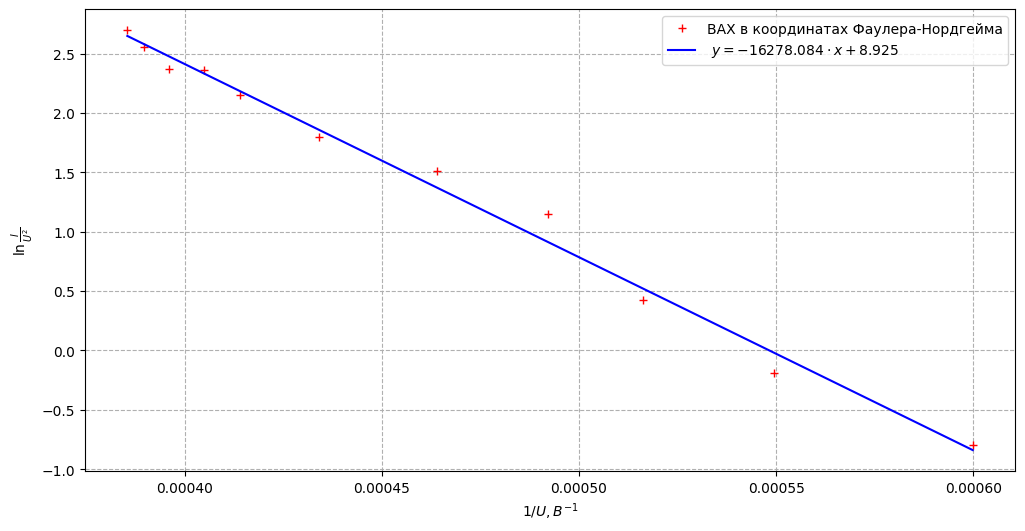

In [11]:
# Последнюю точку выкинул, потому что выброс
popt, _ = plot(x=data_1["1 U"], y=data_1["ln I / U2"], xlabel=r"$1 / U, В^{-1}$", ylabel=r"$\ln {\frac{I}{U^2}}$",
               dots_legend="ВАХ в координатах Фаулера-Нордгейма", name="graph_1_fauler",
               func=straight_func_printer, ejects=[11])
hat_A["1"] = popt[1]
hat_B["1"] = - popt[0]

In [12]:
print(f"hat A = {hat_A["1"]:.2f}")
print(f"hat B = {hat_B["1"]:.0f}")

hat A = 8.92
hat B = 16278


# Имзерение с осцилографом 

(другой катод)

In [13]:
# напряжение зеленого резистора в Омах
R = np.float64('27.2e6')

# Коэффициент для делителя напряжения
V_coef = np.float64('20')

In [5]:
oscilloscope_readings = {}

# Считывание табличек (надо назвать столбец вермени - "T" и напряжения - "V" в каждой таблице, чтобы работало)
for i in '4':
    tmp = []
    for j in '13':
        tmp.append(pd.read_csv(f"F000{i}CH{j}.csv", sep=";"))
    oscilloscope_readings[f"reading_{i}"] = pd.DataFrame({
        "T": tmp[0]["T"],
        "V_CH1": tmp[0]["V"],
        "V_CH2": tmp[1]["V"],
    })

In [15]:
# Посчитаем ток
for read in oscilloscope_readings.keys():
    oscilloscope_readings[read]["I"] = oscilloscope_readings[read]["V_CH2"] / R

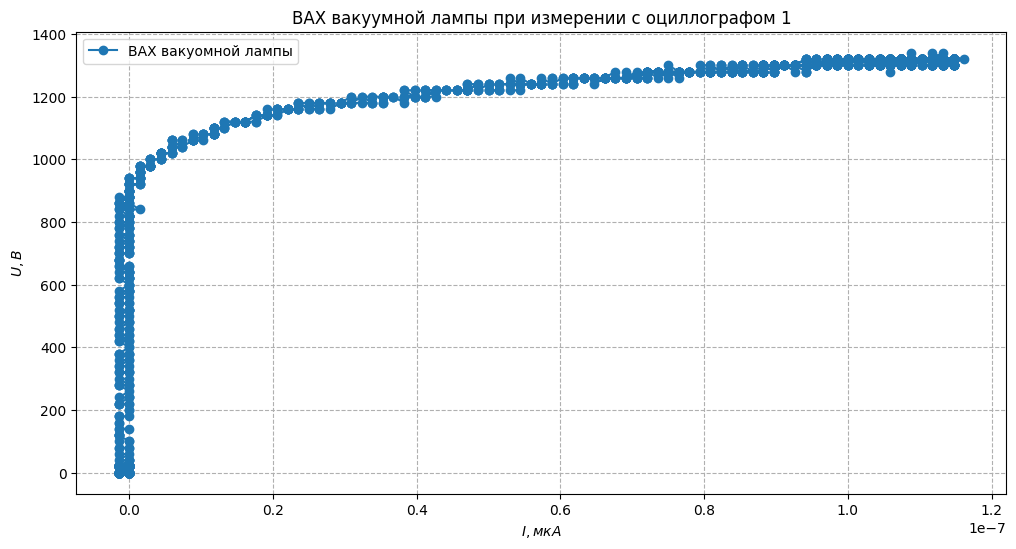

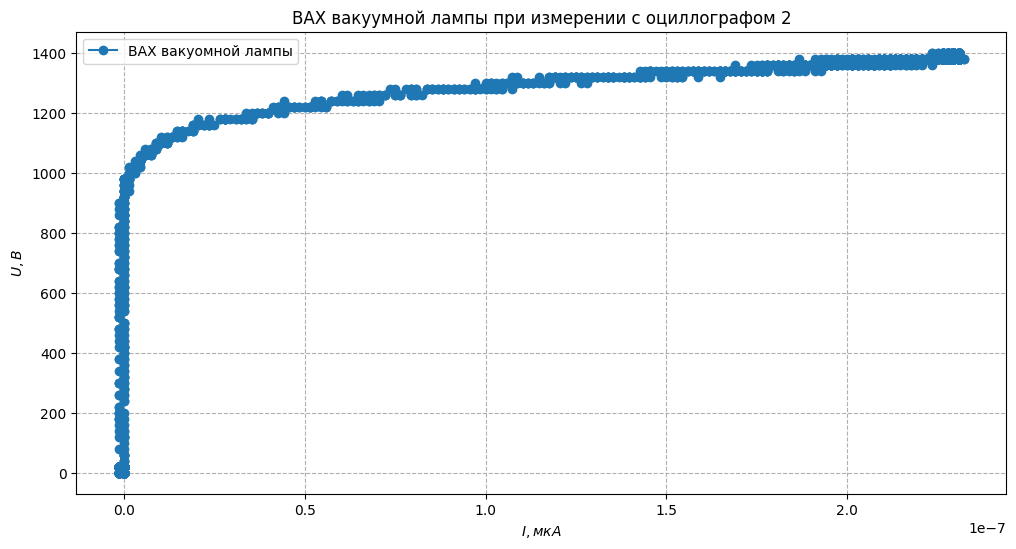

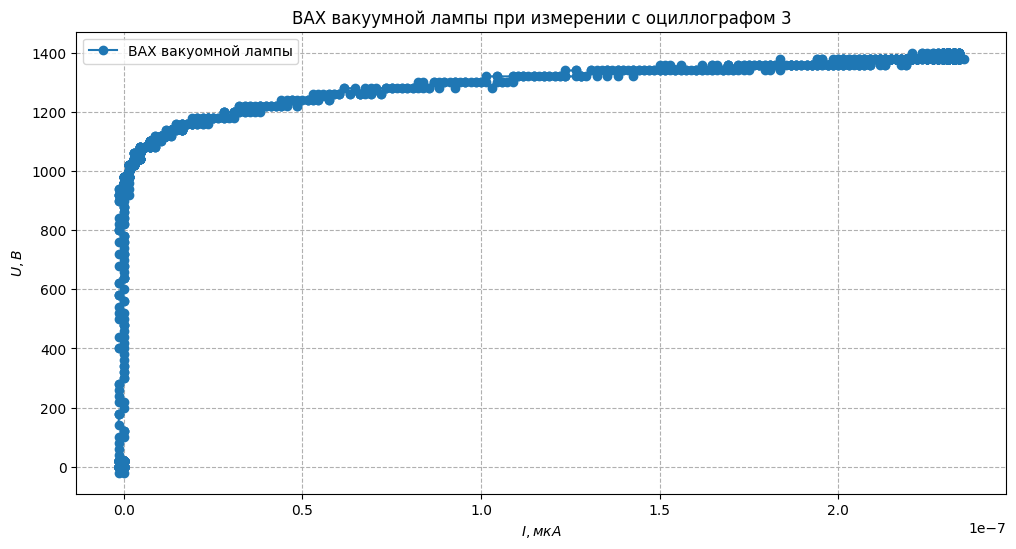

In [16]:
for i in '012':
    _ = plot(oscilloscope_readings[f"reading_{i}"]["I"], oscilloscope_readings[f"reading_{i}"]["V_CH1"], dots_args=['-o'],
             xlabel=r"$I, мкА$", ylabel=r"$U, В$", dots_legend="ВАХ вакуомной лампы", name=f"graph_osc_{i}",
             title=f"ВАХ вакуумной лампы при измерении с оциллографом {int(i) + 1}")
             

In [17]:
# В координаты Фаулера Нордгейма
for i in '012':
    read = f"reading_{i}"
    oscilloscope_readings[read]["ln I / U2"] = np.log(oscilloscope_readings[read]["I"] / np.square(oscilloscope_readings[read]["V_CH1"]))
    oscilloscope_readings[read]["1 U"] = 1 / oscilloscope_readings[read]["V_CH1"]

/home/lev/Documents/gitrepos/Lab_MIPT/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/lev/Documents/gitrepos/Lab_MIPT/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/lev/Documents/gitrepos/Lab_MIPT/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/lev/Documents/gitrepos/Lab_MIPT/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/lev/Documents/gitrepos/Lab_MIPT/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc,

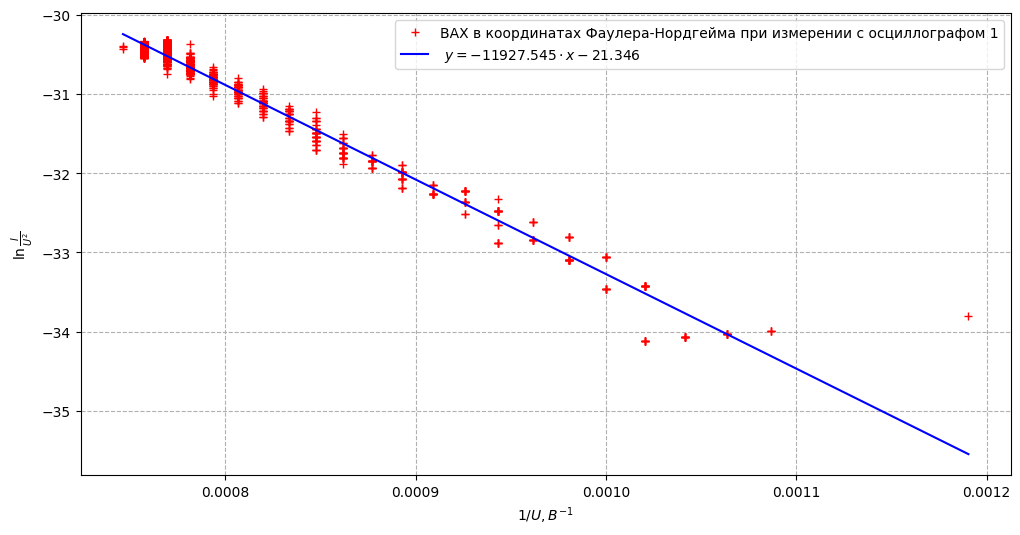

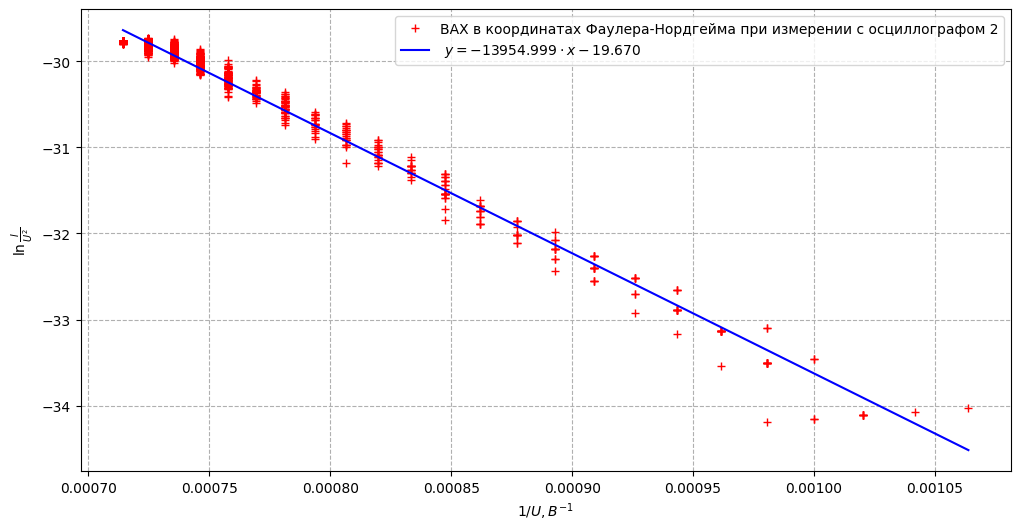

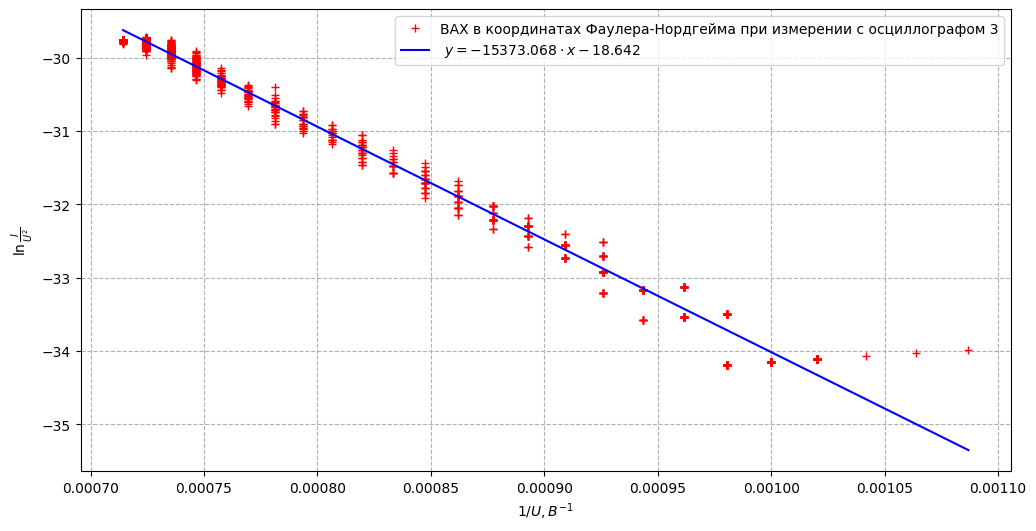

In [18]:
for i in '012':
    read = f"reading_{i}"
    popt, _ = plot(x=oscilloscope_readings[read]["1 U"], y=oscilloscope_readings[read]["ln I / U2"], 
                   xlabel=r"$1 / U, В^{-1}$", ylabel=r"$\ln {\frac{I}{U^2}}$",
                   dots_legend=f"ВАХ в координатах Фаулера-Нордгейма при измерении с осциллографом {int(i) + 1}", name=f"graph_osc_{i}_fauler",
                   func=straight_func_printer, dropna=True)
    
    hat_A[f"osc_{i}"] = popt[1]
    hat_B[f"osc_{i}"] = -popt[0]

In [19]:
for read in hat_A.keys():
    print(f"Измерение {read}")
    print(f"    hat A = {hat_A[read]:.3f}")
    print(f"    hat B = {hat_B[read]:.1f}")

Измерение 1
    hat A = 8.925
    hat B = 16278.1
Измерение osc_0
    hat A = -21.346
    hat B = 11927.5
Измерение osc_1
    hat A = -19.670
    hat B = 13955.0
Измерение osc_2
    hat A = -18.642
    hat B = 15373.1
